In [2]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os

# see what folders are inside
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # only show 3 levels deep
        for file in files[:2]:  # show first 2 files only
            print(f"  {indent}{file}")

chest-xray-pneumonia/
  chest_xray/
    chest_xray/
      .DS_Store
      val/
        PNEUMONIA/
        NORMAL/
      test/
        PNEUMONIA/
        NORMAL/
      train/
        PNEUMONIA/
        NORMAL/
    __MACOSX/
      ._chest_xray
      chest_xray/
        val/
          PNEUMONIA/
          NORMAL/
        test/
          PNEUMONIA/
          NORMAL/
        train/
          PNEUMONIA/
          NORMAL/
    val/
      PNEUMONIA/
      NORMAL/
    test/
      PNEUMONIA/
      NORMAL/
    train/
      PNEUMONIA/
      NORMAL/


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# CONFIG
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 1e-4
IMG_SIZE   = 224

print("Device:", DEVICE)  # should say cuda

# PATHS
TRAIN_DIR = path + "/chest_xray/chest_xray/train"
VAL_DIR   = path + "/chest_xray/chest_xray/val"
TEST_DIR  = path + "/chest_xray/chest_xray/test"

# TRANSFORMS
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# LOAD DATA
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_transforms)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Device: cuda
Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 | Val: 16 | Test: 624


In [5]:
def build_model(num_classes=2):
    model = models.resnet18(weights="IMAGENET1K_V1")
    # loads ResNet18 pretrained on ImageNet
    # it already knows edges, shapes, textures from 1M images

    # FREEZE all layers — don't touch pretrained weights
    for param in model.parameters():
        param.requires_grad = False
    # requires_grad=False means → don't calculate gradients
    # means → don't update these weights during training
    # we're keeping all the knowledge ResNet already has

    # REPLACE only the last layer
    in_features = model.fc.in_features  # 512 for ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        # randomly kills 40% neurons during training
        # forces model to not rely on any single neuron
        # prevents overfitting

        nn.Linear(in_features, num_classes)
        # 512 inputs → 2 outputs (NORMAL, PNEUMONIA)
    )

    return model.to(DEVICE)

model = build_model()
print("model ready!!!")
print("Last layer:", model.fc)

# count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")
# you'll see only ~1000 params trainable out of 11 million
# that's the power of transfer learning!

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s] 


model ready!!!
Last layer: Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)
Trainable params: 1,026 / 11,177,538


In [6]:
# LOSS & OPTIMIZER
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss — standard for classification
# measures how wrong our prediction is
# high loss = very wrong, low loss = nearly right

optimizer = optim.Adam(model.fc.parameters(), lr=LR)
# Adam — smartest basic optimizer
# lr=1e-4 means each step we nudge weights by 0.0001
# model.fc.parameters() — only optimize our new last layer
# NOT the frozen ResNet layers

# ── TRAINING FUNCTION ────────────────────────────────────
def train_one_epoch(model, loader):
    model.train()          # training mode ON (dropout active)
    total_loss, correct = 0, 0

    for images, labels in loader:
        images = images.to(DEVICE)   # send to GPU
        labels = labels.to(DEVICE)   # send to GPU

        optimizer.zero_grad()        # clear gradients from last batch
        outputs = model(images)      # forward pass → get predictions
        loss    = criterion(outputs, labels)  # how wrong are we?
        loss.backward()              # backprop → calculate gradients
        optimizer.step()             # update weights

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        # argmax(1) → which class has higher score (0=NORMAL, 1=PNEUMONIA)

    return total_loss/len(loader), correct/len(loader.dataset)


# ── EVALUATION FUNCTION ──────────────────────────────────
def evaluate(model, loader):
    model.eval()           # eval mode ON (dropout OFF)
    total_loss, correct = 0, 0

    with torch.no_grad():  # don't calculate gradients → faster + saves memory
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss/len(loader), correct/len(loader.dataset)


# ── RUN TRAINING ─────────────────────────────────────────
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
best_val_acc = 0

print("Starting training...\n")

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    vl_loss, vl_acc = evaluate(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    # save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "/content/pneumonia_model.pth")
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} ⬆saved!")
    else:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

print(f"\n ....Training done! Best val acc: {best_val_acc:.4f}")

Starting training...

Epoch 1/10 | Train Loss: 0.5704 Acc: 0.7193 | Val Loss: 0.6294 Acc: 0.5000 ⬆️ saved!
Epoch 2/10 | Train Loss: 0.4094 Acc: 0.8108 | Val Loss: 0.4873 Acc: 0.7500 ⬆️ saved!
Epoch 3/10 | Train Loss: 0.3433 Acc: 0.8551 | Val Loss: 0.3870 Acc: 0.8125 ⬆️ saved!
Epoch 4/10 | Train Loss: 0.3078 Acc: 0.8631 | Val Loss: 0.3764 Acc: 0.7500
Epoch 5/10 | Train Loss: 0.2802 Acc: 0.8842 | Val Loss: 0.3734 Acc: 0.7500
Epoch 6/10 | Train Loss: 0.2645 Acc: 0.8949 | Val Loss: 0.3369 Acc: 0.8125
Epoch 7/10 | Train Loss: 0.2516 Acc: 0.8951 | Val Loss: 0.3163 Acc: 0.8125
Epoch 8/10 | Train Loss: 0.2409 Acc: 0.9053 | Val Loss: 0.2937 Acc: 0.8750 ⬆️ saved!
Epoch 9/10 | Train Loss: 0.2342 Acc: 0.9061 | Val Loss: 0.3618 Acc: 0.7500
Epoch 10/10 | Train Loss: 0.2290 Acc: 0.9080 | Val Loss: 0.3498 Acc: 0.7500

 ....Training done! Best val acc: 0.8750


✅ best model loaded

Test Accuracy: 88.94%
Test Loss:     0.2742

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.83      0.85       234
   PNEUMONIA       0.90      0.93      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



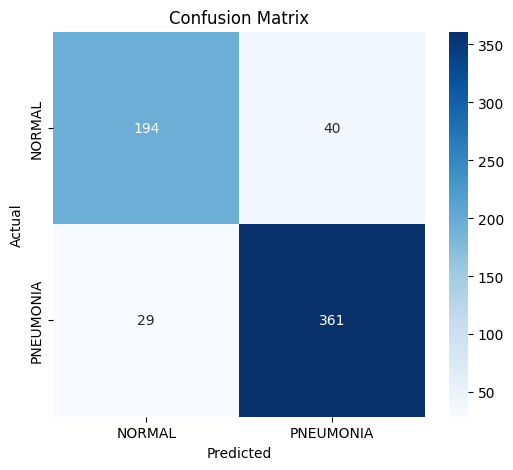

In [7]:
# ── TEST SET EVALUATION ──────────────────────────────────
# load best saved model first
model.load_state_dict(torch.load("/content/pneumonia_model.pth"))
print("best model loaded\n")

# evaluate on test set
test_loss, test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# ── DETAILED REPORT ──────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "PNEUMONIA"]))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["NORMAL","PNEUMONIA"],
            yticklabels=["NORMAL","PNEUMONIA"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


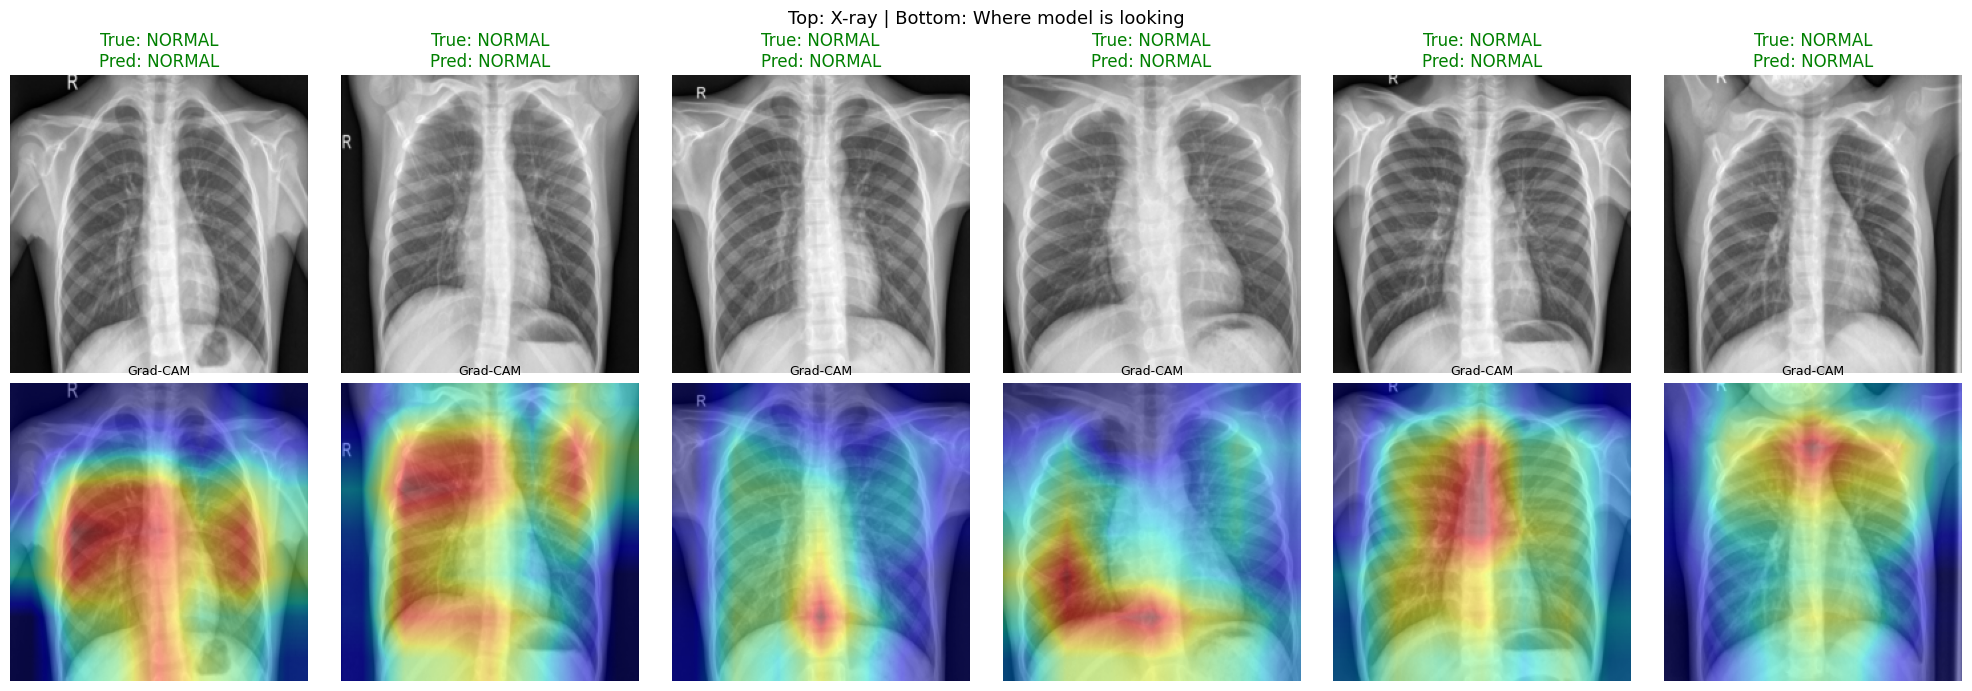

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model      = model
        self.target_layer = target_layer
        self.gradients  = None
        self.activations = None

        # Store the original requires_grad state of the target layer's parameters
        # This is needed to restore the state after Grad-CAM calculation.
        self._original_param_states = {}
        for param in self.target_layer.parameters():
            self._original_param_states[param] = param.requires_grad

    def _save_activation(self, module, input, output):
        # saves feature maps during forward pass
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # saves gradients during backward pass
        # grad_output is a tuple; we need the gradient w.r.t. the output tensor
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        # Temporarily enable gradients for the target layer's parameters
        # This is crucial for gradients to flow back to this layer's output.
        for param in self.target_layer.parameters():
            param.requires_grad_(True)

        # Register hooks. These must be registered before the forward pass that needs them.
        # Store hook handles to remove them later. Using register_full_backward_hook as recommended.
        handle_f = self.target_layer.register_forward_hook(self._save_activation)
        handle_b = self.target_layer.register_full_backward_hook(self._save_gradient)

        # Clear previous gradients and activations
        self.gradients = None
        self.activations = None

        # forward pass
        output = self.model(input_tensor)

        # which class to explain
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # backward pass for that class only
        self.model.zero_grad()
        output[0, class_idx].backward(retain_graph=True) # retain_graph=True if we need to call backward again later

        # Remove hooks immediately after use to prevent memory leaks and ensure clean state
        handle_f.remove()
        handle_b.remove()

        # Restore original requires_grad state of the target layer's parameters
        for param, state in self._original_param_states.items():
            param.requires_grad_(state)

        # Check if gradients were captured. If still None, something is wrong.
        if self.gradients is None:
            raise RuntimeError("Gradients were not captured. Ensure the target layer's output could receive gradients.")

        # global average pooling on gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        # weights = how important is each feature map

        # weighted sum of feature maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # only positive influence
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)

        # normalize to 0-1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy(), class_idx


# ── VISUALIZE ON TEST IMAGES ───────────
gradcam = GradCAM(model, model.layer4[-1])
# layer4 = last conv layer of ResNet
# this is where highest level features live

classes = ["NORMAL", "PNEUMONIA"]

# grab a few test images
sample_images = []
sample_labels = []
for images, labels in test_loader:
    sample_images.append(images)
    sample_labels.append(labels)
    if len(sample_images) * 32 >= 6:
        break

images = torch.cat(sample_images)[:6]
labels = torch.cat(sample_labels)[:6]

# plot
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i in range(6):
    img_tensor = images[i].unsqueeze(0).to(DEVICE)
    true_label = classes[labels[i]]

    # get gradcam heatmap
    cam, pred_idx = gradcam.generate(img_tensor)
    pred_label = classes[pred_idx]

    # original image (unnormalize for display)
    img_np = images[i].permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    # convert to grayscale for xray look
    img_gray = img_np.mean(axis=2)

    # top row ─ original xray
    axes[0, i].imshow(img_gray, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    axes[0, i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    axes[0, i].axis('off')

    # bottom row ─ xray + heatmap overlay
    axes[1, i].imshow(img_gray, cmap='gray')
    axes[1, i].imshow(cam, cmap='jet', alpha=0.45)
    # alpha=0.45 ─ heatmap is semi-transparent over xray
    axes[1, i].set_title("Grad-CAM", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle("Top: X-ray | Bottom: Where model is looking", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ── UPLOAD WIDGET ────────────────────────────────────────
upload_btn = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',  # only image files
    multiple=False,
    description='Upload X-ray'
)

run_btn = widgets.Button(
    description='Analyze X-ray ',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px')
)

output_area = widgets.Output()

# ── PREDICTION FUNCTION ──────────────────────────────────
def analyze_xray(btn):
    with output_area:
        clear_output()

        # check if image uploaded
        if len(upload_btn.value) == 0:
            print("⚠️ please upload an xray image first!")
            return

        # read uploaded image
        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file['content']
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

        # preprocess — same as val_transforms
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

        img_tensor = transform(img).unsqueeze(0).to(DEVICE)
        # unsqueeze(0) → adds batch dimension
        # [3, 224, 224] → [1, 3, 224, 224]

        # ── PREDICTION ───────────────────────────────────
        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
            probs  = torch.softmax(output, dim=1)[0]
            # softmax converts raw scores → probabilities that sum to 1

        pred_idx   = probs.argmax().item()
        pred_label = ["NORMAL", "PNEUMONIA"][pred_idx]
        confidence = probs[pred_idx].item() * 100

        # ── GRAD-CAM ─────────────────────────────────────
        cam, _ = gradcam.generate(img_tensor, class_idx=pred_idx)

        # ── DISPLAY ──────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # original image
        img_display = np.array(img.resize((224, 224)))
        img_gray    = np.mean(img_display, axis=2)

        axes[0].imshow(img_gray, cmap='gray')
        axes[0].set_title("Uploaded X-ray", fontsize=13)
        axes[0].axis('off')

        # gradcam heatmap only
        axes[1].imshow(cam, cmap='jet')
        axes[1].set_title("Grad-CAM Heatmap", fontsize=13)
        axes[1].axis('off')

        # overlay
        axes[2].imshow(img_gray, cmap='gray')
        axes[2].imshow(cam, cmap='jet', alpha=0.45)
        axes[2].set_title("Overlay", fontsize=13)
        axes[2].axis('off')

        # result text
        color = 'red' if pred_label == 'PNEUMONIA' else 'green'
        fig.suptitle(
            f"Prediction: {pred_label}  |  Confidence: {confidence:.1f}%",
            fontsize=15,
            color=color,
            fontweight='bold'
        )

        plt.tight_layout()
        plt.show()

        # probability bar
        print(f"\n{'='*40}")
        print(f"  NORMAL    : {probs[0]*100:.1f}%  {'█' * int(probs[0]*30)}")
        print(f"  PNEUMONIA : {probs[1]*100:.1f}%  {'█' * int(probs[1]*30)}")
        print(f"{'='*40}")

        if pred_label == 'PNEUMONIA':
            print("\n⚠️  This X-ray shows signs of Pneumonia.")
            print("    Please consult a doctor immediately.")
        else:
            print("\n✅  This X-ray appears Normal.")
            print("    Still consult a doctor for confirmation.")

# ── CONNECT BUTTON ───────────────────────────────────────
run_btn.on_click(analyze_xray)

# ── DISPLAY UI ───────────────────────────────────────────
print("🏥 X-ray Pneumonia Analyzer")
print("─" * 35)
display(upload_btn, run_btn, output_area)

🏥 X-ray Pneumonia Analyzer
───────────────────────────────────


FileUpload(value={}, accept='.jpg,.jpeg,.png', description='Upload X-ray')

Button(button_style='primary', description='Analyze X-ray ', layout=Layout(height='40px', width='200px'), styl…

Output()